In [1]:
import os, glob, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cpu')
print('Device:', DEVICE)

Device: cpu


In [2]:
SYNTHETIC_DATA = False
DAPT_BASE = '/kaggle/input/datasets/sowmyamyneni/dapt2020/csv'
DAPT_CSV_PATHS = {
    1: [f'{DAPT_BASE}/enp0s3-monday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-monday-pvt.pcap_Flow.csv'],
    2: [f'{DAPT_BASE}/enp0s3-public-tuesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-tuesday.pcap_Flow.csv'],
    3: [f'{DAPT_BASE}/enp0s3-public-wednesday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-wednesday.pcap_Flow.csv'],
    4: [f'{DAPT_BASE}/enp0s3-public-thursday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-pvt-thursday.pcap_Flow.csv'],
    5: [f'{DAPT_BASE}/enp0s3-tcpdump-friday.pcap_Flow.csv', f'{DAPT_BASE}/enp0s3-tcpdump-pvt-friday.pcap_Flow.csv'],
}
DAPT_LABEL_COL = 'Label'

# ============================================================
# MAPPING NHÃN → APT PHASE (0..4)
# ============================================================
ATTACK_TO_PHASE = {
    # Phase 0 — Benign
    'Benign': 0, 'benign': 0, 'BENIGN': 0, 'Normal': 0, 'normal': 0,
    # Phase 1 — Reconnaissance
    'Network Scan': 1, 'NetworkScan': 1, 'network scan': 1,
    'Web vulnerability Scan': 1, 'Web Vulnerability Scan': 1,
    'WebVulnerabilityScan': 1, 'Port Scan': 1, 'PortScan': 1,
    'Reconnaissance': 1,
    # Phase 2 — Foothold
    'SQL injection': 2, 'SQL Injection': 2, 'SQLInjection': 2,
    'Backdoor': 2, 'backdoor': 2,
    'Malware Download': 2, 'MalwareDownload': 2,
    'Command Injection': 2, 'CommandInjection': 2,
    'CSRF': 2, 'csrf': 2,
    'Account brute force': 2, 'AccountBruteForce': 2, 'BruteForce': 2,
    'Foothold': 2,
    # Phase 3 — Lateral Movement
    'DoS': 3, 'dos': 3, 'DenialOfService': 3,
    'Privilege escalation': 3, 'PrivilegeEscalation': 3,
    'Lateral Movement': 3, 'LateralMovement': 3,
    # Phase 4 — Exfiltration
    'Data Exfiltration': 4, 'DataExfiltration': 4,
    'Exfiltration': 4, 'exfiltration': 4,
}
APT_PHASE_NAMES = [
    'Benign', 'Reconnaissance', 'Foothold', 'Lateral Movement', 'Exfiltration'
]
N_APT_PHASES = len(APT_PHASE_NAMES)

# ============================================================
# HYPERPARAMETERS
# ============================================================
N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 4
EPOCHS      = 10
LR          = 1e-3
D_MODEL     = 256
N_HEADS     = 8
N_PERSIST   = 4
SWA_WINDOW  = 16
LMM_LAYERS  = 2          # Số lớp của LTM deep MLP
LMM_DROPOUT = 0.1        # Dropout trong NeuralLongTermMemory
HEAD_DROPOUT = 0.1       # Dropout trong classification head
OUTLIER_TH  = 3.0
PRE_BATCH   = 50_000

# Synthetic-only params
N_SYNTHETIC = 5000
N_FEATURES  = 40

print(f'Mode : {"SYNTHETIC" if SYNTHETIC_DATA else "REAL DAPT 2020 (sowmyamyneni/dapt2020)"}')
print(f'Phases: {N_APT_PHASES} | D_MODEL={D_MODEL} | Epochs={EPOCHS}')
if not SYNTHETIC_DATA:
    for day, paths in DAPT_CSV_PATHS.items():
        for path in paths:
            status = '✅' if os.path.exists(path) else '❌'
            print(f'  Day {day}: {os.path.basename(path)} {status}')

Mode : REAL DAPT 2020 (sowmyamyneni/dapt2020)
Phases: 5 | D_MODEL=256 | Epochs=10
  Day 1: enp0s3-monday.pcap_Flow.csv ✅
  Day 1: enp0s3-monday-pvt.pcap_Flow.csv ✅
  Day 2: enp0s3-public-tuesday.pcap_Flow.csv ✅
  Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv ✅
  Day 3: enp0s3-public-wednesday.pcap_Flow.csv ✅
  Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv ✅
  Day 4: enp0s3-public-thursday.pcap_Flow.csv ✅
  Day 4: enp0s3-pvt-thursday.pcap_Flow.csv ✅
  Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv ✅
  Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv ✅


In [3]:
def generate_synthetic_dapt(n_per_phase=1000, n_features=40, seed=42):
    np.random.seed(seed)
    dfs = []
    configs = [
        (0.3, 0.1, []),
        (0.5, 0.3, [0, 1, 2]),
        (0.6, 0.4, [5, 6, 7]),
        (0.7, 0.3, [10, 11]),
        (0.9, 0.5, [15, 16]),
    ]
    for phase_id, (mu, sigma, skew) in enumerate(configs):
        data = np.abs(np.random.randn(n_per_phase, n_features) * sigma + mu)
        for f in skew:
            data[:, f] += np.random.exponential(2.0, n_per_phase)
        df_p = pd.DataFrame(data, columns=[f'f{i}' for i in range(n_features)])
        df_p['APT_Phase'] = phase_id
        dfs.append(df_p)
    return pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


def load_real_dapt(csv_paths, attack_to_phase, label_col_hint='Stage'):
    """Load DAPT 2020 từ Kaggle (sowmyamyneni/dapt2020) có xử lý header tự động."""
    # Bước 1: Thu thập tất cả các file tồn tại
    all_files = []
    for day, paths in csv_paths.items():
        if not isinstance(paths, list):
            paths = [paths]
        for path in paths:
            if os.path.exists(path):
                all_files.append((day, path))
            else:
                print(f'  [Day {day}] ⚠️ Không tìm thấy, bỏ qua: {path}')

    if not all_files:
        raise FileNotFoundError(f'Không tìm thấy bất kỳ file CSV nào tại: {DAPT_BASE}')

    # Bước 2: Tìm file có header để lấy bộ cột chuẩn
    standard_cols = None
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        # Check xem dòng đầu có chứa các từ khóa tiêu biểu của header không
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])
        if has_header:
            df_temp = pd.read_csv(path, nrows=5)
            standard_cols = list(df_temp.columns)
            print(f'  -> Lấy bộ cột chuẩn từ file có header: {os.path.basename(path)} ({len(standard_cols)} cột)')
            break

    if standard_cols is None:
        raise ValueError("Không tìm thấy file nào có header để lấy danh sách cột chuẩn!")

    # Bước 3: Load tất cả các file (cả có header và không header)
    dfs = []
    for day, path in all_files:
        with open(path, 'r', errors='ignore') as f:
            first_line = f.readline()
        has_header = any(h in first_line.lower() for h in ["flow id", "flow_id", "src ip", "src_ip", "protocol", "timestamp"])

        print(f'Loading Day {day}: {os.path.basename(path)} (Has Header: {has_header}) ...')
        try:
            if has_header:
                df_d = pd.read_csv(path, low_memory=False)
                # Đảm bảo giữ đúng số lượng và thứ tự cột chuẩn
                df_d = df_d.reindex(columns=standard_cols)
            else:
                # File không có header -> dùng standard_cols
                df_d = pd.read_csv(path, header=None, names=standard_cols, low_memory=False)
            
            df_d['Day'] = day
            dfs.append(df_d)
        except Exception as e:
            print(f'  ❌ Lỗi khi đọc file {os.path.basename(path)}: {e}')

    if not dfs:
        raise ValueError("Không load được dataframe nào.")

    df = pd.concat(dfs, ignore_index=True)
    print(f'Concat shape: {df.shape}')

    # Bước 4: Xác định cột nhãn (Stage hoặc Activity)
    label_col = None
    search_cols = []
    if label_col_hint:
        search_cols.append(label_col_hint)
    search_cols.extend(['Stage', 'stage', 'Activity', 'activity', 'Label', 'label', 'Attack', 'attack', 'Class', 'Category'])
    
    for c in search_cols:
        if c in df.columns:
            label_col = c
            break

    if label_col is None:
        raise ValueError(f'Không tìm thấy cột nhãn. Cột hiện có: {list(df.columns)}')
    print(f'Cột nhãn được chọn: "{label_col}"')

    # Hiển thị nhãn thực tế
    print('\nNhãn thực tế trong cột nhãn:')
    for lbl in sorted(df[label_col].dropna().unique()):
        print(f'  "{lbl}": {(df[label_col]==lbl).sum():,}')

    # Map nhãn → Phase
    df['APT_Phase'] = df[label_col].astype(str).map(attack_to_phase)
    unmapped = df['APT_Phase'].isna()
    if unmapped.any():
        print(f'⚠️ {unmapped.sum():,} rows unmapped → fallback theo Day')
        df.loc[unmapped, 'APT_Phase'] = df.loc[unmapped, 'Day'].map({1:0, 2:1, 3:2, 4:3, 5:4})
    df['APT_Phase'] = df['APT_Phase'].fillna(0).astype(int)

    print('\nPhase Distribution:')
    for i, name in enumerate(APT_PHASE_NAMES):
        cnt = (df['APT_Phase']==i).sum()
        print(f'  Phase {i} ({name:<22}): {cnt:>10,} ({cnt/len(df)*100:5.1f}%)')
    
    return df, label_col


# -------- LOAD --------
if SYNTHETIC_DATA:
    print('🔬 Synthetic Mode')
    df = generate_synthetic_dapt(N_SYNTHETIC // N_APT_PHASES, N_FEATURES)
    feature_cols = [c for c in df.columns if c != 'APT_Phase']
else:
    print('📂 Real DAPT 2020')
    df, _lc = load_real_dapt(DAPT_CSV_PATHS, ATTACK_TO_PHASE, DAPT_LABEL_COL)
    drop = {'APT_Phase', 'Day', _lc, 'Label', 'label', 'Attack', 'attack', 'Class', 'Category'}
    const_cols = set(df.std(numeric_only=True).pipe(lambda s: s[s==0]).index)
    feature_cols = [c for c in df.columns
                    if c not in drop | const_cols
                    and pd.api.types.is_numeric_dtype(df[c])]
    print(f'Feature cols: {len(feature_cols)}')

X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['APT_Phase'].values.astype(np.int64)
print(f'\nX={X_raw.shape} | y={y_raw.shape} | Classes={N_APT_PHASES}')


📂 Real DAPT 2020
  -> Lấy bộ cột chuẩn từ file có header: enp0s3-monday.pcap_Flow.csv (85 cột)
Loading Day 1: enp0s3-monday.pcap_Flow.csv (Has Header: True) ...
Loading Day 1: enp0s3-monday-pvt.pcap_Flow.csv (Has Header: True) ...
Loading Day 2: enp0s3-public-tuesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 2: enp0s3-pvt-tuesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 3: enp0s3-public-wednesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 3: enp0s3-pvt-wednesday.pcap_Flow.csv (Has Header: True) ...
Loading Day 4: enp0s3-public-thursday.pcap_Flow.csv (Has Header: True) ...
Loading Day 4: enp0s3-pvt-thursday.pcap_Flow.csv (Has Header: False) ...
Loading Day 5: enp0s3-tcpdump-friday.pcap_Flow.csv (Has Header: True) ...
Loading Day 5: enp0s3-tcpdump-pvt-friday.pcap_Flow.csv (Has Header: True) ...
Concat shape: (86691, 86)
Cột nhãn được chọn: "Stage"

Nhãn thực tế trong cột nhãn:
  "BENIGN": 19,454
  "Benign": 44,258
  "Data Exfiltration": 15
  "Establish Foothold": 8,6

In [4]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_raw, y_raw, test_size=0.3, stratify=y_raw, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}')
del X_raw, X_tmp, y_tmp; gc.collect()

Train: (60683, 67) | Val: (8669, 67) | Test: (17339, 67)


0

In [5]:
def robust_clean(X_tr, X_val, X_te, batch=50_000, th=3.0):
    """Xử lý NaN / Inf / Outlier theo batch."""
    print('🔄 Robust cleaning...')
    for arr in [X_tr, X_val, X_te]:
        if hasattr(arr, 'values'): arr = arr.values
    X_tr  = X_tr.astype(np.float32)
    X_val = X_val.astype(np.float32)
    X_te  = X_te.astype(np.float32)

    s = min(100_000, len(X_tr))
    idx = np.random.choice(len(X_tr), s, replace=False)
    med = np.nanmedian(X_tr[idx], axis=0)
    std = np.nanstd(X_tr[idx],    axis=0); std[std==0] = 1.0

    def clean(A):
        out = []
        for i in range(0, len(A), batch):
            B = A[i:i+batch].copy()
            B[np.isinf(B)] = np.nan
            for c in range(B.shape[1]):
                m = med[c]
                bad = np.isnan(B[:,c]) | (np.abs((B[:,c]-m)/std[c]) > th)
                B[bad, c] = m
            out.append(np.clip(B, -1e6, 1e6))
        return np.vstack(out)

    Xtr, Xva, Xte = clean(X_tr), clean(X_val), clean(X_te)
    print(f'  ✅ NaN={np.isnan(Xtr).any()} | Inf={np.isinf(Xtr).any()}')
    return Xtr, Xva, Xte


X_tr, X_val, X_te = robust_clean(X_tr, X_val, X_te, PRE_BATCH, OUTLIER_TH)

# PCA
nc = min(N_PCA, X_tr.shape[1])
pca = PCA(n_components=nc, random_state=SEED)
X_tr  = pca.fit_transform(X_tr)
X_val = pca.transform(X_val)
X_te  = pca.transform(X_te)
print(f'PCA: {nc} components | variance={pca.explained_variance_ratio_.sum()*100:.1f}%')

# StandardScaler
sc = StandardScaler()
X_tr  = sc.fit_transform(X_tr)
X_val = sc.transform(X_val)
X_te  = sc.transform(X_te)

# KBins tokenize
kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr).astype(np.int64)
tok_val = kbd.transform(X_val).astype(np.int64)
tok_te  = kbd.transform(X_te).astype(np.int64)

vocab = [int(max(tok_tr[:,i].max(), tok_val[:,i].max(), tok_te[:,i].max())) + 2
         for i in range(tok_tr.shape[1])]
SEQ_LEN = tok_tr.shape[1]
print(f'Token shape: {tok_tr.shape} | vocab sample: {vocab[:5]}')

🔄 Robust cleaning...
  ✅ NaN=False | Inf=False
PCA: 20 components | variance=99.5%
Token shape: (60683, 20) | vocab sample: [33, 33, 33, 33, 33]


## 5. Dataset & DataLoader

In [6]:
class TokenDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
train_loader = DataLoader(TokenDS(tok_tr,  y_tr),  BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
val_loader   = DataLoader(TokenDS(tok_val, y_val), BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(TokenDS(tok_te,  y_te),  BATCH_SIZE, shuffle=False, **kw)
print(f'Batches — train:{len(train_loader)} | val:{len(val_loader)} | test:{len(test_loader)}')

Batches — train:59 | val:9 | test:17


## 5. TITAN

In [7]:
class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v in vocab_sizes])
        self.pos  = nn.Embedding(len(vocab_sizes), d)
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        B, L = x.shape
        h = torch.stack([self.embs[i](x[:,i]) for i in range(L)], dim=1)
        p = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(h + self.pos(p))

class NeuralLongTermMemory(nn.Module):
    """
    Buoc 3+4 — LTM / LMM theo Section 3.1 cua Titans:
    Ban than neural memory la mot HiddenMLP (Deep Residual Bottleneck MLP)
    thay vi MLP tuan tu thong thuong, giup:
      - Tranh vanishing gradient khi cap nhat bo nho test-time
      - Tang kha nang ghi nho anh xa Key-Value phuc tap hon
      - On dinh qua trinh toi uu nho LayerNorm + Residual connections
    Forward : M(k) + Mt   — HiddenMLP recall
    Backprop: gradient update Mt (test-time learning)
    """
    def __init__(self, d, num_blocks=2, dropout=0.1):
        super().__init__()

        # === 1. FFN + Activation Function ===
        # Inlined Deep Residual Bottleneck MLP (tuong duong HiddenMLP)
        hidden = d // 2
        self.M_blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm': nn.LayerNorm(d),
                'fc1':  nn.Linear(d, hidden),
                'act':  nn.ReLU(),          # Activation Function
                'drop': nn.Dropout(dropout),
                'fc2':  nn.Linear(hidden, d),
            }) for _ in range(num_blocks)
        ])
        self.M_norm = nn.LayerNorm(d)

        # === 2. Backpropagating (Test-time Learning Gates) ===
        # Dieu khien qua trinh cap nhat gradient vao bo nho tai test-time
        self.alpha = nn.Linear(d, 1)   # Forget gate — quyet dinh bo bao nhieu ky uc cu
        self.eta   = nn.Linear(d, 1)   # Momentum   — quan tinh cap nhat gradient
        self.theta = nn.Linear(d, 1)   # Learning rate — toc do hoc test-time

        # === 3. Attention (Key / Value / Query Projections) ===
        self.key   = nn.Linear(d, d)
        self.value = nn.Linear(d, d)
        self.query = nn.Linear(d, d)

        # === 4. Weighted Layer Perceptron (Output Projection) ===
        self.out_proj = nn.Linear(d, d)  # Chieu output cuoi cua bo nho
        self.norm     = nn.LayerNorm(d)

    def _M(self, x):
        """Residual Bottleneck MLP forward (inlined HiddenMLP)."""
        for b in self.M_blocks:
            h = b['norm'](x)
            h = b['fc2'](b['drop'](b['act'](b['fc1'](h))))
            x = x + h
        return self.M_norm(x)

    def forward(self, h):
        B, L, D = h.shape
        k = self.key(h);   v = self.value(h);   q = self.query(h)
        a = torch.sigmoid(self.alpha(h))
        e = torch.sigmoid(self.eta(h))
        t = torch.sigmoid(self.theta(h)) * 0.1
        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for i in range(L):
            v_hat = self._M(k[:,i]) + Mt          # forward: Residual MLP recall
            St = e[:,i]*St - t[:,i]*2*(v_hat - v[:,i])   # momentum update
            Mt = (1 - a[:,i])*Mt + St              # memory state
            outs.append(self.out_proj(self._M(q[:,i]) + Mt))  # Weighted Perceptron output
        return self.norm(torch.stack(outs, dim=1))


class SlidingWindowAttention(nn.Module):
    """Buoc 5 — Co che Chu y: causal SWA voi cua so W."""
    def __init__(self, d, n_heads, window=16):
        super().__init__()
        self.attn   = nn.MultiheadAttention(d, n_heads, batch_first=True)
        self.norm   = nn.LayerNorm(d)
        self.window = window
    def forward(self, x):
        L   = x.size(1)
        idx = torch.arange(L, device=x.device)
        d   = idx.unsqueeze(0) - idx.unsqueeze(1)
        mask = (d > 0) | (d < -(self.window - 1))
        y, _ = self.attn(x, x, x, attn_mask=mask, need_weights=False)
        return self.norm(x + y)


class TitanMAG(nn.Module):
    """
    Titan — Memory as a Gate (MAG).

    Luong xu ly chuan theo workflow:
      1. FeatureEmbedding              — bieu dien token
         prepend persistent tokens
      2. [SWA || LMM] song song:
         - SWA = Co che Chu y (Attention)
         - LMM = HiddenMLP bo nho (Residual Bottleneck + test-time Backprop)
      3. combine + gate_norm
      4. head (WeightedPerceptron)     — Tinh trong so -> Output
    """
    def __init__(self, vocab_sizes, n_classes,
                 d=64, n_heads=4, n_persist=4, swa_window=16,
                 lmm_blocks=2, lmm_dropout=0.1):
        super().__init__()
        self.embed      = FeatureEmbedding(vocab_sizes, d)
        self.P          = nn.Parameter(torch.randn(1, n_persist, d) * 0.02)
        # Buoc 3+4: Attention || LTM (HiddenMLP lam bo nho) song song
        self.swa    = SlidingWindowAttention(d, n_heads, swa_window)
        self.lmm    = NeuralLongTermMemory(d, num_blocks=lmm_blocks, dropout=lmm_dropout)
        self.merge  = nn.Linear(d * 2, d)
        self.gate   = nn.Linear(d, d)
        self.gate_norm = nn.LayerNorm(d)
        # Buoc 5: Weighted Perceptron -> Output
        self.head   = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d),
            nn.ReLU(),
            nn.Dropout(HEAD_DROPOUT),
            nn.Linear(d, n_classes)
        )
        self.np = n_persist

    def forward(self, x):
        B = x.size(0)
        h = self.embed(x)                                    # (B, L, d)

        # Prepend persistent tokens (embed -> straight to memory/attention)
        xt = torch.cat([self.P.expand(B,-1,-1), h], dim=1)  # (B, P+L, d)

        # Buoc 3+4: Attention || LTM deep MLP
        y_swa = self.swa(xt)                                 # (B, P+L, d)
        y_lmm = self.lmm(xt)                                 # (B, P+L, d)

        out = self.merge(torch.cat([y_swa, y_lmm], dim=-1))  # (B, P+L, d)
        out = self.gate_norm(out * torch.sigmoid(self.gate(xt)))  # gate

        out = out[:, self.np:].mean(dim=1)                   # pool, bo persistent
        return self.head(out)


model = TitanMAG(vocab, N_APT_PHASES,
                 d=D_MODEL, n_heads=N_HEADS, n_persist=N_PERSIST,
                 swa_window=SWA_WINDOW,
                 lmm_blocks=LMM_LAYERS, lmm_dropout=LMM_DROPOUT).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'TitanMAG workflow: Embed->[SWA||LMM(HiddenMLP)]-gate->WeightedPerceptron')
print(f'Params: {total:,}')

TitanMAG workflow: Embed->[SWA||LMM(HiddenMLP)]-gate->WeightedPerceptron
Params: 1,102,344


## 7. Training

In [8]:
def run_eval(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).argmax(-1).cpu().numpy())
            trues.append(yb.numpy())
    p, t = np.concatenate(preds), np.concatenate(trues)
    return dict(
        acc  = accuracy_score(t, p),
        f1   = f1_score(t, p, average='weighted', zero_division=0),
        prec = precision_score(t, p, average='weighted', zero_division=0),
        rec  = recall_score(t, p, average='weighted', zero_division=0),
        pred = p, true = t
    )


# Weighted CE Loss — Cross Entropy Loss co trong so xu ly mat can bang lop
class_counts = np.bincount(y_tr, minlength=N_APT_PHASES)
weights = torch.tensor(len(y_tr) / (N_APT_PHASES * np.maximum(class_counts, 1)),
                       dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('Training TitanMAG (DimReduce->HiddenMLP->[SWA||LMM-DeepMLP]->WeightedPerceptron)...')
history = []
for ep in range(1, EPOCHS + 1):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()
    m = run_eval(model, val_loader)
    history.append({'ep': ep, 'loss': np.mean(losses), **{k: m[k] for k in ['acc','f1','prec','rec']}})
    print(f'[Epoch {ep}/{EPOCHS}] loss={np.mean(losses):.4f} | '
          f'acc={m["acc"]:.4f} | f1={m["f1"]:.4f} | prec={m["prec"]:.4f} | rec={m["rec"]:.4f}')


Training TitanMAG (DimReduce->HiddenMLP->[SWA||LMM-DeepMLP]->WeightedPerceptron)...
[Epoch 1/10] loss=0.9765 | acc=0.8781 | f1=0.8878 | prec=0.9019 | rec=0.8781
[Epoch 2/10] loss=0.5105 | acc=0.8705 | f1=0.8867 | prec=0.9165 | rec=0.8705
[Epoch 3/10] loss=0.4583 | acc=0.8768 | f1=0.8932 | prec=0.9239 | rec=0.8768
[Epoch 4/10] loss=0.2700 | acc=0.8926 | f1=0.9054 | prec=0.9296 | rec=0.8926
[Epoch 5/10] loss=0.2487 | acc=0.8983 | f1=0.9082 | prec=0.9274 | rec=0.8983
[Epoch 6/10] loss=0.2066 | acc=0.9040 | f1=0.9117 | prec=0.9292 | rec=0.9040
[Epoch 7/10] loss=0.1860 | acc=0.9098 | f1=0.9160 | prec=0.9293 | rec=0.9098
[Epoch 8/10] loss=0.1580 | acc=0.9004 | f1=0.9089 | prec=0.9288 | rec=0.9004
[Epoch 9/10] loss=0.1438 | acc=0.9098 | f1=0.9158 | prec=0.9303 | rec=0.9098
[Epoch 10/10] loss=0.1344 | acc=0.9108 | f1=0.9167 | prec=0.9306 | rec=0.9108


## 8. Đánh giá Test + Confusion Matrix


===== TEST METRICS (APT Phase Detection) =====
Accuracy        : 0.9069
F1  (weighted)  : 0.9138
F1  (macro)     : 0.6853
Precision (w)   : 0.9304
Recall    (w)   : 0.9069

                  precision    recall  f1-score   support

          Benign       0.99      0.90      0.94     12743
  Reconnaissance       0.72      0.91      0.80      2382
        Foothold       0.88      0.95      0.92      1719
Lateral Movement       0.56      0.92      0.69       490
    Exfiltration       0.04      0.60      0.07         5

        accuracy                           0.91     17339
       macro avg       0.64      0.86      0.69     17339
    weighted avg       0.93      0.91      0.91     17339



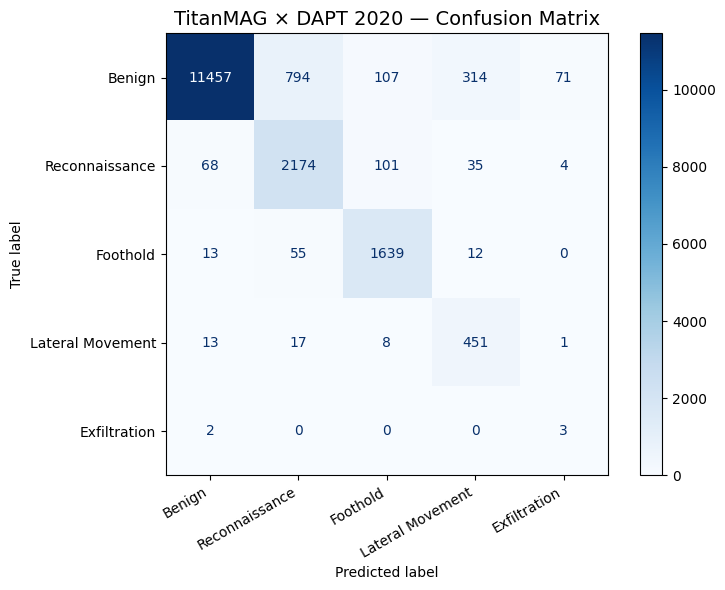

In [9]:
m = run_eval(model, test_loader)
print('\n===== TEST METRICS (APT Phase Detection) =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1  (weighted)  : {m["f1"]:.4f}')
print(f'F1  (macro)     : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall    (w)   : {m["rec"]:.4f}')
print()
print(classification_report(m['true'], m['pred'],
                             target_names=APT_PHASE_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=APT_PHASE_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('TitanMAG × DAPT 2020 — Confusion Matrix', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dapt2020_confusion_matrix.png', dpi=150)
plt.show()